<a href="https://colab.research.google.com/github/a01645643/BI26_Yuli/blob/main/M3_A1_Noise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Ultrasound Fetus Dataset** | Imagen 100_HC.png de la carpeta de Datasets > bening

Link de datasets de las imagenes: https://www.kaggle.com/datasets/orvile/ultrasound-fetus-dataset?resource=download

In [35]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [18]:
# semilla para replicabilidad
SEED = 42
np.random.seed(SEED)

# carga correcta de imagen
img_raw = mpimg.imread('/content/drive/MyDrive/100_HC.png')

# convertir a escala de grises si tiene canales RGB
if len(img_raw.shape) == 3:
    imagen_original = np.mean(img_raw[:, :, :3], axis=2)
else:
    imagen_original = img_raw

# convertir a float64
imagen_original = imagen_original.astype(np.float64)

# dimensiones
H, W = imagen_original.shape

# verificación
print(imagen_original.min(), imagen_original.max())
print(imagen_original.shape)

0.0 0.9529411792755127
(540, 800)


In [19]:
print(img_raw.dtype)
print(img_raw.min())
print(img_raw.max())
print(img_raw.shape)

float32
0.0
0.9529412
(540, 800)


In [20]:
def salt_and_pepper(imagen, densidad=0.04, seed=SEED):
    rng = np.random.default_rng(seed)
    img_ruidosa = imagen.copy()
    n = int(densidad * H * W)

    filas_sal = rng.integers(0, H, n // 2)
    cols_sal  = rng.integers(0, W, n // 2)
    img_ruidosa[filas_sal, cols_sal] = 1.0

    filas_pim = rng.integers(0, H, n // 2)
    cols_pim  = rng.integers(0, W, n // 2)
    img_ruidosa[filas_pim, cols_pim] = 0.0

    return np.clip(img_ruidosa, 0.0, 1.0)



In [29]:
def gaussiano(imagen, media=0.0, sigma=0.05, seed=SEED):
    rng = np.random.default_rng(seed)
    ruido = rng.normal(media, sigma, imagen.shape)
    return np.clip(imagen + ruido, 0.0, 1.0)

In [30]:
def speckle(imagen, varianza=0.04, seed=SEED):
    rng = np.random.default_rng(seed)
    ruido = rng.normal(0, varianza**0.5, imagen.shape)
    return np.clip(imagen + imagen * ruido, 0.0, 1.0)


In [31]:
def poisson(imagen, factor_escala=50.0, seed=SEED):
    rng = np.random.default_rng(seed)
    img_escalada = np.maximum(imagen * factor_escala, 0)
    img_poisson  = rng.poisson(img_escalada).astype(np.float64)
    return np.clip(img_poisson / factor_escala, 0.0, 1.0)

In [32]:
def tv_analogica(imagen, seed=SEED):
    rng = np.random.default_rng(seed)

    # nieve
    nieve = rng.normal(0, 0.08, imagen.shape)

    # bandas horizontales
    ganancia = 1.0 + 0.12 * np.sin(
        np.linspace(0, 8 * np.pi, H) + rng.uniform(0, 2 * np.pi)
    ) + rng.normal(0, 0.03, H)
    bandas = (ganancia[:, np.newaxis] - 1.0) * imagen

    # fantasma desplazado
    dx = int(W * 0.07)
    fantasma = np.zeros_like(imagen)
    fantasma[:, dx:] = imagen[:, :-dx] * 0.18

    return np.clip(imagen + nieve + bandas + fantasma, 0.0, 1.0)

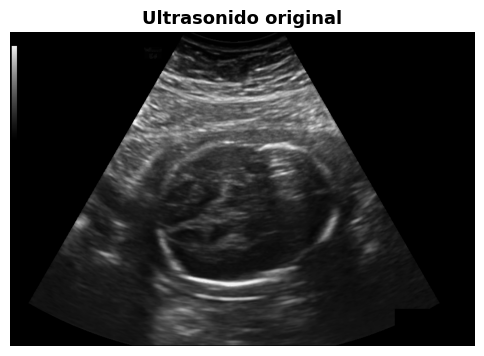

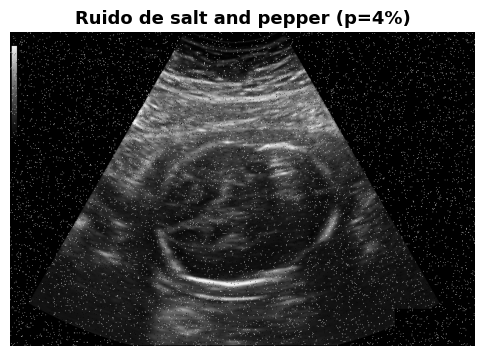

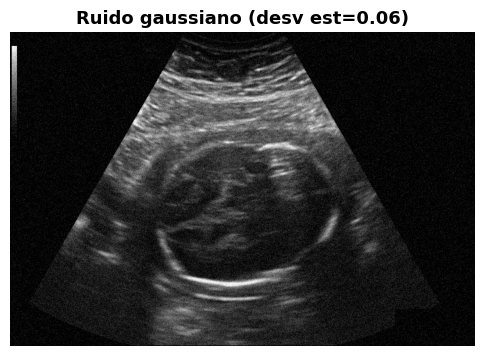

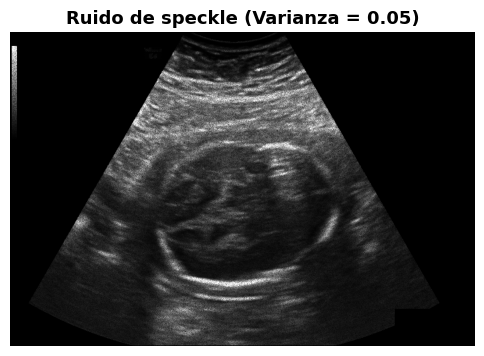

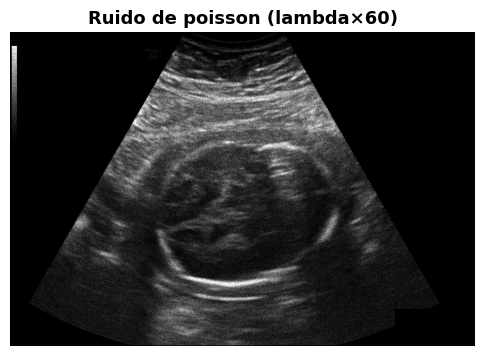

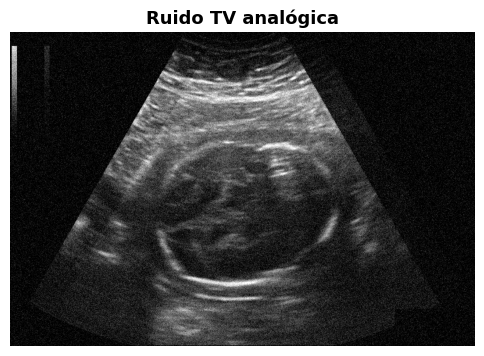

In [33]:
def mostrar_imagen(imagen, titulo):
    plt.figure(figsize=(6,6))
    plt.imshow(imagen, cmap='gray', vmin=0, vmax=1)
    plt.title(titulo, fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.show()

mostrar_imagen(imagen_original, 'Ultrasonido original')
mostrar_imagen(img_sp, 'Ruido de salt and pepper (p=4%)') # p = densidad de ruido
mostrar_imagen(img_gauss, 'Ruido gaussiano (desv est=0.06)') # desviación estandard
mostrar_imagen(img_speckle, 'Ruido de speckle (Varianza = 0.05)')
mostrar_imagen(img_poisson, 'Ruido de poisson (lambda×60)') # 60 es el factor de escala
mostrar_imagen(img_tv, 'Ruido TV analógica')


In [34]:
def calcular_snr(ref, ruidosa):
    diferencia = ref - ruidosa
    return 10 * np.log10(np.mean(ref**2) / (np.mean(diferencia**2) + 1e-12))

print(' SNR en dB ')
for nombre, img in [
    ('Salt-and-Pepper', img_sp),
    ('Gaussiano      ', img_gauss),
    ('Speckle        ', img_speckle),
    ('Poisson        ', img_poisson),
    ('TV Analógica   ', img_tv),
]:
    print(f"  {nombre}: {calcular_snr(imagen_original, img):.2f} dB")

 SNR en dB 
  Salt-and-Pepper: 3.95 dB
  Gaussiano      : 11.78 dB
  Speckle        : 13.13 dB
  Poisson        : 13.12 dB
  TV Analógica   : 7.95 dB
